# Dust Attenuation Gallery

_dust_gallery

## Part 1: Attenuation curves


Visual reference for the attenuation laws registered in
``tengri.models.dust.attenuation.DUST_LAWS``. Each law is obtained with
``resolve_dust_law(name)`` (registry lookup per the naming contract) and
evaluated on a common wavelength grid. The forward model applies them through
``two_component_dust`` (Charlot \& Fall--style birth cloud + diffuse ISM).

**Paper §3 forward chain:** dust attenuation (and IR re-radiation in Part 2) follows stellar
SPS and nebular/AGN emission, and precedes IGM and observation projections.

Each curve $k(\lambda)$ describes how dust attenuation varies with wavelength,
normalized at 5500 A (V-band). The two-component model then applies separate
curves with independent optical depths for birth clouds and diffuse ISM:

$$\tau(\lambda, \mathrm{age}) = w(\mathrm{age})\,\tau_\mathrm{bc}\,k_\mathrm{bc}(\lambda)
  + \tau_\mathrm{diff}\,k_\mathrm{diff}(\lambda)$$

**Sections:**

1. Overview -- all curves at default parameters
2. Empirical average curves (Calzetti, Leitherer)
3. Modified Calzetti family (KC13, N09, SBL18)
4. MW / SMC / LMC extinction curves
5. Physics-motivated curves (TEA, Conroy2010, Narayanan)
6. Parameter exploration (incl. Li et al. 2008 $c_1$--$c_4$)
7. Dust geometries (WG00)
8. Two-component dust model
9. Summary table

In [1]:
import importlib.util
import os
import sys
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri.models.dust.attenuation import (
    DUST_LAWS,
    li08,
    precompute_dust_age_weights,
    resolve_dust_law,
    two_component_dust,
    wg00_cloudy,
    wg00_dusty,
    wg00_shell,
)

_nbooks = os.path.join(_repo_root, "notebooks")
if os.path.isdir(_nbooks):
    sys.path.insert(0, _nbooks)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

try:
    from _plot_style import COLORS, setup_style
except ModuleNotFoundError:
    from tengri.plotting import setup_style

    COLORS = {}

setup_style()

FIGDIR = os.path.join("notebooks", "figures", "dust_gallery")
os.makedirs(FIGDIR, exist_ok=True)

## 1. Overview -- All Curves at Default Parameters

Every key in ``DUST_LAWS`` evaluated at default parameters on a common grid
(100--25000 Å): a single place to see the shapes tengri exposes via
``resolve_dust_law``.

Curves are grouped by family:
- **Empirical averages** (solid): Calzetti, Leitherer
- **Modified Calzetti** (dashed): Kriek-Conroy, Noll09, SBL18, Salim
- **Extinction curves** (dotted): Cardelli MW, SMC, LMC
- **Physics-motivated** (dash-dot): TEA, Conroy2010, Narayanan
- **Parametric** (solid thin): power_law, Li08

In [ ]:
wave = jnp.linspace(100.0, 25000.0, 2000)

# Group curves for colour and linestyle consistency
_GROUPS = {
    "Empirical averages": {
        "curves": ["calzetti", "leitherer02"],
        "ls": "-",
        "lw": 2.2,
    },
    "Modified Calzetti": {
        "curves": ["kriek_conroy", "noll09", "salim_sbl18", "salim"],
        "ls": "--",
        "lw": 1.8,
    },
    "Extinction (MW/SMC/LMC)": {
        "curves": ["cardelli", "smc", "lmc"],
        "ls": ":",
        "lw": 2.2,
    },
    "Physics-motivated": {
        "curves": ["tea", "conroy2010", "narayanan_z"],
        "ls": "-.",
        "lw": 1.8,
    },
    "Parametric": {
        "curves": ["power_law", "li08"],
        "ls": "-",
        "lw": 1.2,
    },
}

# Human-readable labels for each curve
_LABELS = {
    "power_law": "Power law (CF00)",
    "calzetti": "Calzetti (C00)",
    "leitherer02": "Leitherer (L02)",
    "kriek_conroy": "Kriek-Conroy (KC13)",
    "noll09": "Noll (N09)",
    "salim_sbl18": "Salim-Boquien-Lee (SBL18)",
    "salim": "Salim (S18, = KC13)",
    "cardelli": "Cardelli MW (CCM89)",
    "smc": "SMC (Pei 1992)",
    "lmc": "LMC (Pei 1992)",
    "li08": "Li (L08) parametric",
    "tea": "TEA (Haskell+2024)",
    "conroy2010": "Conroy (C10)",
    "narayanan_z": "Narayanan (N18, z=0)",
}

# Colormap: 14 distinct colours
_cm = plt.cm.tab20(np.linspace(0, 1, 20))
_CURVE_COLORS = {}
_ci = 0
for group_info in _GROUPS.values():
    for name in group_info["curves"]:
        _CURVE_COLORS[name] = _cm[_ci]
        _ci += 1

fig, ax = plt.subplots(figsize=(10, 6))

for _group_name, group_info in _GROUPS.items():
    for name in group_info["curves"]:
        fn = resolve_dust_law(name)
        k = fn(wave)
        ax.plot(
            np.array(wave),
            np.array(k),
            label=_LABELS[name],
            color=_CURVE_COLORS[name],
            ls=group_info["ls"],
            lw=group_info["lw"],
        )

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$ (normalized at 5500 $\AA$)")
ax.set_title("All 14 Dust Attenuation Curves at Default Parameters")
ax.set_xlim(900, 8000)
ax.set_ylim(0, 8)
ax.axvline(5500, color="grey", ls=":", alpha=0.5, label=r"$\lambda_V = 5500\,\AA$")
ax.axvline(2175, color="grey", ls="--", alpha=0.3, label=r"2175 $\AA$ bump")
ax.legend(fontsize=16, ncol=2, loc="upper right", framealpha=0.9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_all_attenuation_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Empirical Average Curves

The two workhorse empirical attenuation curves for star-forming galaxies:

- **Calzetti et al. (2000)**: the starburst standard, derived from UV-optical
  spectroscopy of 39 starburst galaxies. Fixed $R_V = 4.05$ (greyer than MW).
  Valid 1200--22000 A.

- **Leitherer et al. (2002)**: extends the Calzetti curve into the far-UV
  (970--1800 A) using *IUE* + *FUSE* spectroscopy. Essential for rest-frame
  UV photometry of high-$z$ galaxies.

Below we plot both together, highlighting where L02 extends beyond C00.

In [2]:
wave_uv = jnp.linspace(900.0, 25000.0, 2000)

k_c00 = resolve_dust_law("calzetti")(wave_uv)
k_l02 = resolve_dust_law("leitherer02")(wave_uv)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(np.array(wave_uv), np.array(k_c00), color=COLORS["rt"], lw=2.5, label="Calzetti (C00)")
ax.plot(
    np.array(wave_uv),
    np.array(k_l02),
    color=COLORS["vi"],
    lw=2.5,
    ls="--",
    label="Leitherer (L02)",
)

# Highlight the L02 extension region
ax.axvspan(970, 1200, alpha=0.15, color=COLORS["vi"], label="L02 extension (970--1200 A)")
ax.axvspan(1200, 1800, alpha=0.08, color=COLORS["vi"])

ax.axvline(1200, color="grey", ls=":", alpha=0.4)
ax.annotate(
    "C00 lower limit\n(1200 A)",
    xy=(1200, 4.5),
    fontsize=8,
    ha="center",
    color="grey",
)
ax.axvline(5500, color="grey", ls=":", alpha=0.3)

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("Empirical Average Curves: Calzetti (C00) vs Leitherer (L02)")
ax.set_xlim(900, 6000)
ax.set_ylim(0, 5)
ax.legend(fontsize=12, loc="upper right")
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_calzetti_vs_leitherer.png"), dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/ssp.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## 3. Modified Calzetti Family

Three popular modifications to the Calzetti curve that add a **UV bump** at
2175 A and a **power-law slope** modification $\delta$:

- **Kriek & Conroy (2013)**: $k(\lambda) = k_\mathrm{C00}(\lambda) \cdot
  (\lambda/5500)^\delta + E_b \cdot D(\lambda, 2175\,\AA)$.
  Bump is added *after* the slope.

- **Noll et al. (2009)**: $k(\lambda) = [k'_\mathrm{L02+C00}(\lambda) +
  E_b \cdot D(\lambda)] \cdot (\lambda/0.55)^\delta / R_V$.
  Bump is applied *before* the slope.

- **Salim, Boquien & Lee (2018)**: $k(\lambda) = [k'_\mathrm{L02+C00}(\lambda)
  \cdot (\lambda/0.55)^\delta + E_b \cdot D(\lambda)] / R_V$.
  Bump is added *after* the slope (same as KC13), but uses L02 in the far-UV.

The ordering difference is subtle but physically meaningful. Below we show all
three at $\delta = -0.3$, $E_b = 1.5$, with a UV-zoom inset.

NameError: name 'model' is not defined

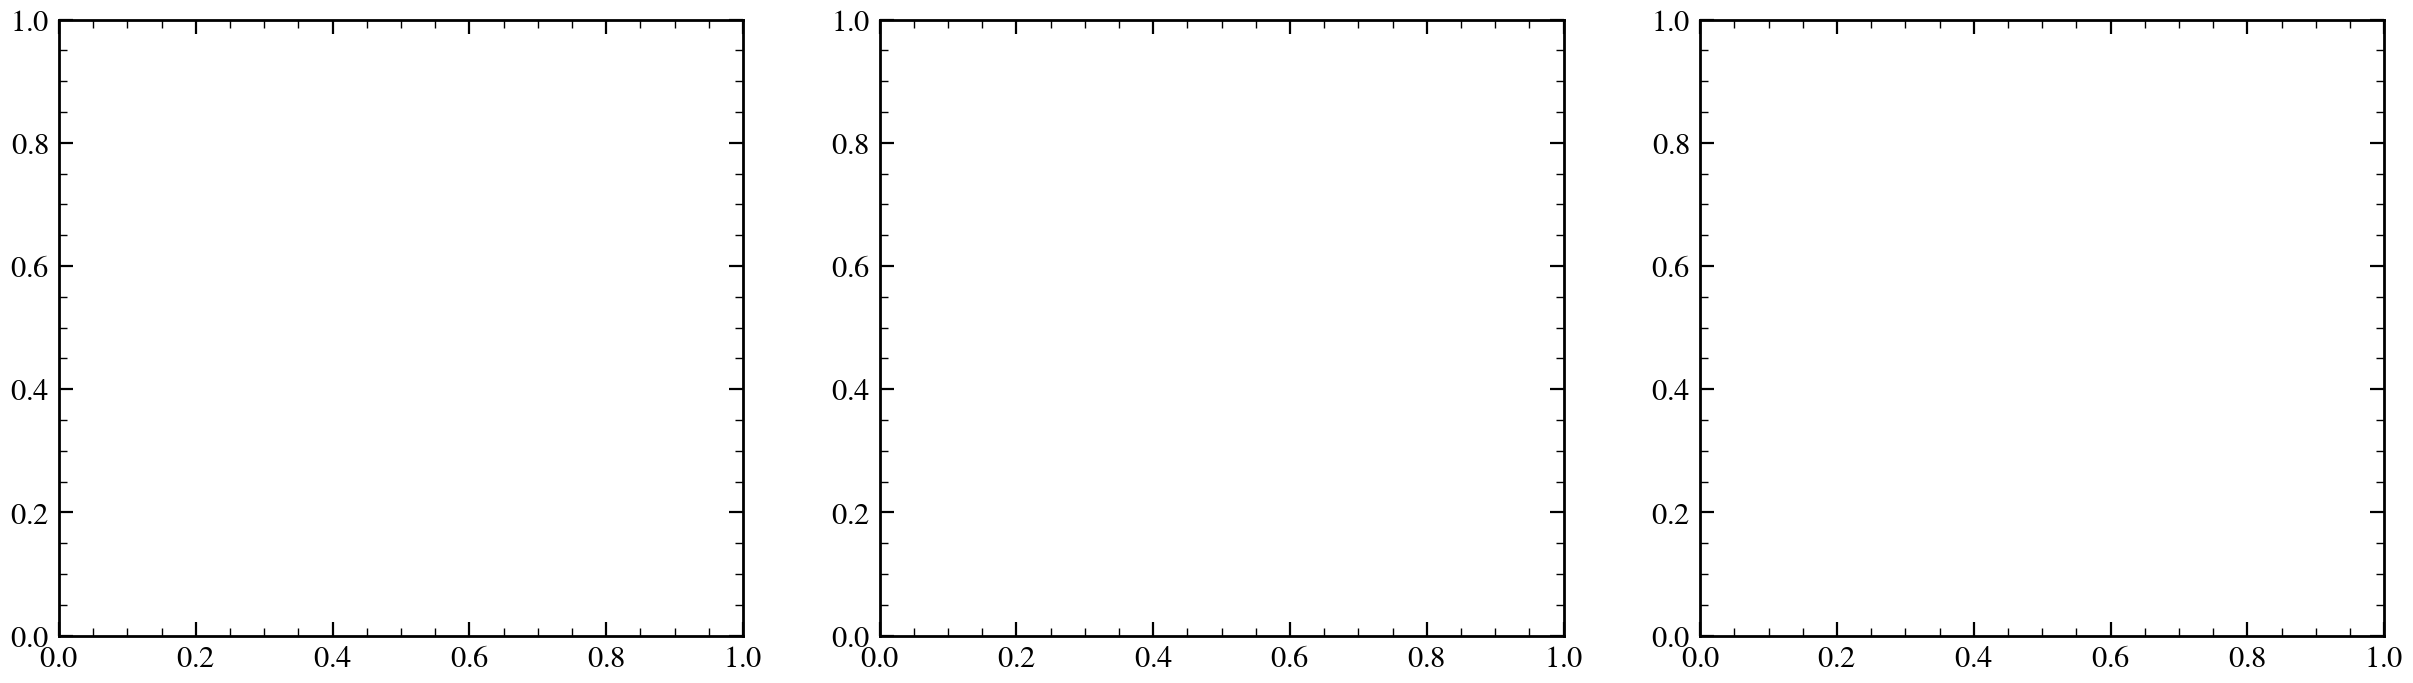

In [3]:
wave_mod = jnp.linspace(1000.0, 15000.0, 2000)

delta = -0.3
bump = 1.5

k_kc13 = resolve_dust_law("kriek_conroy")(wave_mod, dust_delta=delta, dust_bump_strength=bump)
k_n09 = resolve_dust_law("noll09")(wave_mod, dust_delta=delta, dust_bump_strength=bump)
k_sbl18 = resolve_dust_law("salim_sbl18")(wave_mod, dust_delta=delta, dust_bump_strength=bump)
k_c00 = resolve_dust_law("calzetti")(wave_mod)

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[2, 1])

# Main panel
for k_arr, label, color, ls in [
    (k_c00, "Calzetti (reference)", "grey", ":"),
    (k_kc13, r"KC13: base$\times$slope + bump", COLORS["rt"], "-"),
    (k_n09, r"N09: (base + bump)$\times$slope", COLORS["vi"], "--"),
    (k_sbl18, r"SBL18: base$\times$slope + bump (+ L02)", COLORS["mcmc_nuts"], "-."),
]:
    ax_main.plot(np.array(wave_mod), np.array(k_arr), label=label, color=color, ls=ls, lw=2)

ax_main.axvline(2175, color="grey", ls="--", alpha=0.3, label=r"2175 $\AA$")
ax_main.set_xlabel(r"Wavelength ($\AA$)")
ax_main.set_ylabel(r"$k(\lambda)$")
ax_main.set_title(rf"Modified Calzetti Family ($\delta={delta}$, $E_b={bump}$)")
ax_main.set_xlim(1000, 10000)
ax_main.set_ylim(0, 10)
ax_main.legend(fontsize=12, loc="upper right")

# UV zoom panel
uv_mask = np.array(wave_mod) < 4000
for k_arr, label, color, ls in [
    (k_c00, "C00", "grey", ":"),
    (k_kc13, "KC13", COLORS["rt"], "-"),
    (k_n09, "N09", COLORS["vi"], "--"),
    (k_sbl18, "SBL18", COLORS["mcmc_nuts"], "-."),
]:
    ax_zoom.plot(
        np.array(wave_mod)[uv_mask],
        np.array(k_arr)[uv_mask],
        label=label,
        color=color,
        ls=ls,
        lw=2,
    )

ax_zoom.axvline(2175, color="grey", ls="--", alpha=0.3)
ax_zoom.axvspan(2050, 2300, alpha=0.08, color="purple")
ax_zoom.set_xlabel(r"Wavelength ($\AA$)")
ax_zoom.set_ylabel(r"$k(\lambda)$")
ax_zoom.set_title("UV Bump Region (zoom)")
ax_zoom.set_xlim(1000, 4000)
ax_zoom.legend(fontsize=12)

fig.tight_layout()
# fig.savefig(
# os.path.join(FIGDIR, "15_modified_calzetti_family.png"),
# dpi=150,
# bbox_inches="tight",
# )
plt.show()

## 4. MW / SMC / LMC Extinction Curves

Classical extinction curves from the Milky Way and Magellanic Clouds,
which differ primarily in the strength of the **2175 A bump**:

- **Cardelli et al. (1989)**: MW average with a strong 2175 A bump. Free
  parameter $R_V = A_V / E(B-V)$ controls the ratio of total to selective
  extinction (steeper UV for lower $R_V$). Default $R_V = 3.1$.

- **SMC** (Pei 1992): steep far-UV rise, essentially **no** 2175 A bump.
  Common in high-redshift and metal-poor galaxies. $R_V = 2.93$.

- **LMC** (Pei 1992): intermediate -- a **weak** 2175 A bump, steeper
  than MW but shallower than SMC. $R_V = 3.16$.

In [ ]:
wave_ext = jnp.linspace(1000.0, 25000.0, 2000)

k_mw = resolve_dust_law("cardelli")(wave_ext, dust_Rv=3.1)
k_smc = resolve_dust_law("smc")(wave_ext)
k_lmc = resolve_dust_law("lmc")(wave_ext)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    np.array(wave_ext), np.array(k_mw), color=COLORS["rt"], lw=2.5, label="MW (CCM89, R_V=3.1)"
)
ax.plot(np.array(wave_ext), np.array(k_smc), color=COLORS["vi"], lw=2.5, label="SMC (Pei 1992)")
ax.plot(np.array(wave_ext), np.array(k_lmc), color=COLORS["mcmc_nuts"], lw=2.5, label="LMC (Pei 1992)")

# Highlight the bump region
ax.axvspan(2050, 2300, alpha=0.1, color="purple", label=r"2175 $\AA$ bump region")
ax.axvline(2175, color="grey", ls="--", alpha=0.4)

# Annotations for bump strength
ax.annotate(
    "Strong bump",
    xy=(2175, np.float64(k_mw[np.argmin(np.abs(np.array(wave_ext) - 2175))])),
    xytext=(3000, 6.5),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": COLORS["rt"]},
    color=COLORS["rt"],
)
ax.annotate(
    "No bump",
    xy=(2175, np.float64(k_smc[np.argmin(np.abs(np.array(wave_ext) - 2175))])),
    xytext=(3500, 4.0),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": COLORS["vi"]},
    color=COLORS["vi"],
)
ax.annotate(
    "Weak bump",
    xy=(2175, np.float64(k_lmc[np.argmin(np.abs(np.array(wave_ext) - 2175))])),
    xytext=(3200, 5.2),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": COLORS["mcmc_nuts"]},
    color=COLORS["mcmc_nuts"],
)

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda) = A(\lambda) / A(V)$")
ax.set_title("Milky Way, SMC, and LMC Extinction Curves")
ax.set_xlim(1000, 6000)
ax.set_ylim(0, 10)
ax.legend(fontsize=12, loc="upper right")
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_mw_smc_lmc.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Physics-Motivated Curves

These curves are calibrated on **radiative-transfer simulations** of galaxies,
providing physically motivated relationships between attenuation parameters.

### 5a. TEA (Haskell+2024)

The Turbulent Empirical Attenuation model from NIHAO-SKIRT simulations
encodes a tight **correlation** between the UV bump strength $E_b$ and the
slope modification $\delta$:

$$E_b(\delta) = 2.5 \exp(3.5\,\delta) \times 10^{\mathrm{scatter}}$$

Steeper curves (more negative $\delta$) have weaker bumps. This reduces the
Kriek-Conroy 2-parameter space to a 1D track.

### 5b. Conroy+2010

A smooth blend of MW (Cardelli) in the UV and a power law in the IR,
joined by a sigmoid at 5500 A. Used in FSPS as `dust_type=1`.

### 5c. Narayanan+2018

Redshift-dependent Kriek-Conroy with median parameters calibrated on
SIMBA cosmological radiative-transfer simulations. At higher redshift,
curves become steeper and the bump weakens.

NameError: name 'model' is not defined

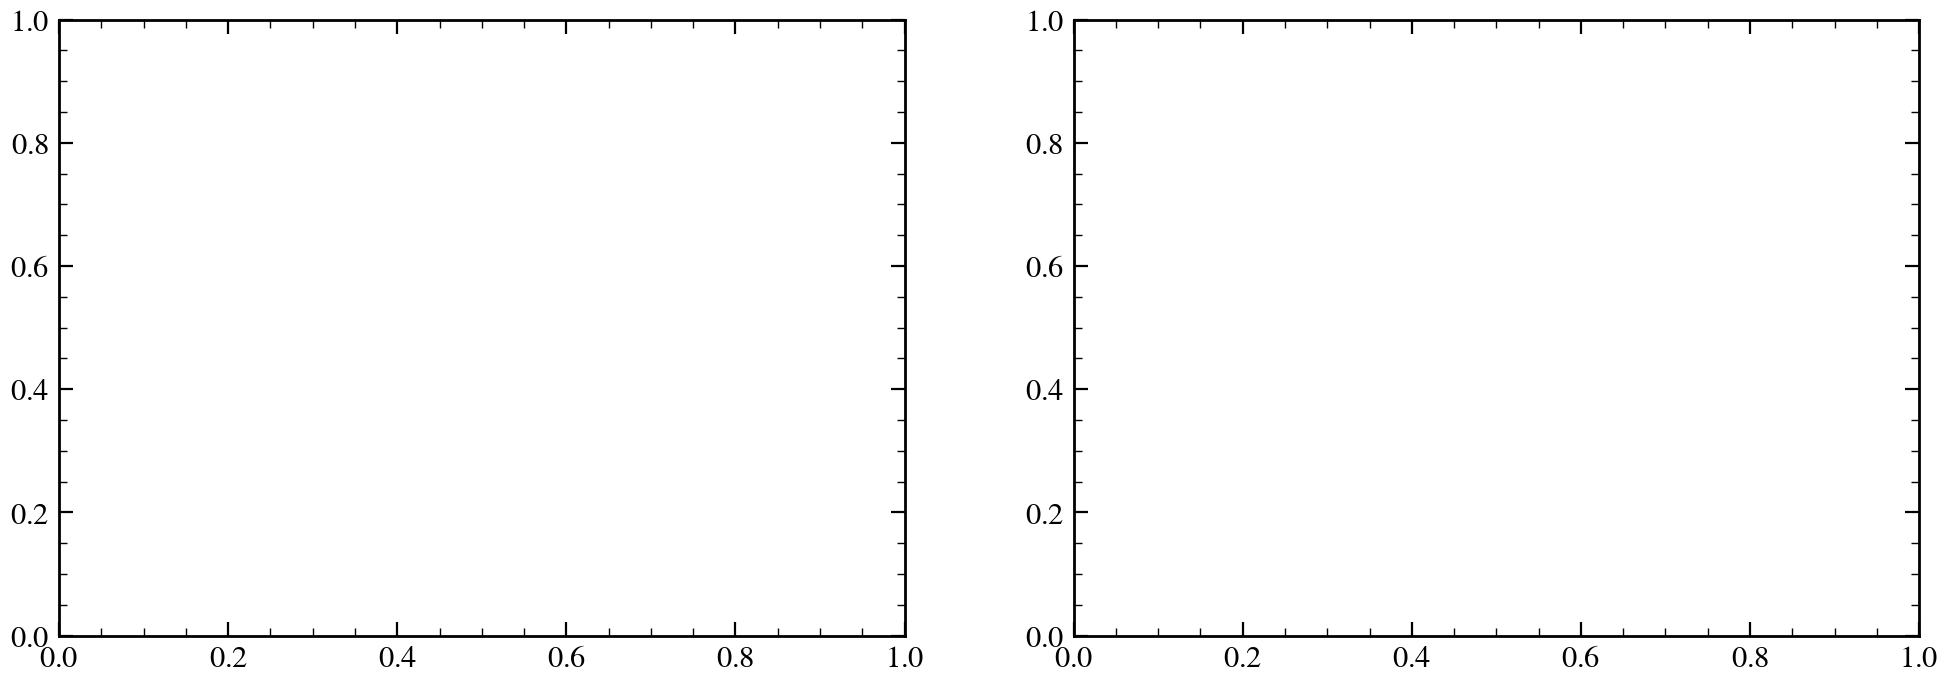

In [4]:
wave_phys = jnp.linspace(1000.0, 15000.0, 2000)

# 5a. TEA: show delta sweep with the E_b(delta) correlation
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# TEA
ax = axes[0]
deltas_tea = [-0.6, -0.4, -0.2, 0.0, 0.2]
tea_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(deltas_tea)))
for delta_val, c in zip(deltas_tea, tea_colors):
    k_tea = resolve_dust_law("tea")(wave_phys, dust_delta=delta_val)
    eb_val = 2.5 * np.exp(3.5 * delta_val)
    ax.plot(
        np.array(wave_phys),
        np.array(k_tea),
        color=c,
        lw=2,
        label=rf"$\delta={delta_val:.1f}$, $E_b={eb_val:.2f}$",
    )
ax.axvline(2175, color="grey", ls="--", alpha=0.3)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("TEA: $E_b(\\delta)$ Correlation")
ax.set_xlim(1000, 10000)
ax.set_ylim(0, 8)
ax.legend(fontsize=7, loc="upper right")

# 5b. Conroy2010: show MW/power-law blend
ax = axes[1]
k_con = resolve_dust_law("conroy2010")(wave_phys)
k_mw_ref = resolve_dust_law("cardelli")(wave_phys, dust_Rv=3.1)
k_pl_ref = resolve_dust_law("power_law")(wave_phys, n_slope=-0.7)
ax.plot(np.array(wave_phys), np.array(k_con), color=COLORS["rt"], lw=2.5, label="Conroy2010 blend")
ax.plot(
    np.array(wave_phys),
    np.array(k_mw_ref),
    color="grey",
    lw=1.5,
    ls=":",
    label="Cardelli MW (R_V=3.1)",
)
ax.plot(
    np.array(wave_phys),
    np.array(k_pl_ref),
    color="grey",
    lw=1.5,
    ls="--",
    label="Power law (n=-0.7)",
)
ax.axvline(5500, color="grey", ls=":", alpha=0.3, label="Blend transition")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("Conroy+2010: MW + Power Law Blend")
ax.set_xlim(1000, 15000)
ax.set_ylim(0, 8)
ax.legend(fontsize=7, loc="upper right")

# 5c. Narayanan: show z-evolution
ax = axes[2]
redshifts = [0.0, 1.0, 3.0, 6.0]
z_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(redshifts)))
for z_val, c in zip(redshifts, z_colors):
    # Use default delta/bump to trigger z-dependent scaling
    k_nz = resolve_dust_law("narayanan_z")(wave_phys, redshift=z_val)
    ax.plot(np.array(wave_phys), np.array(k_nz), color=c, lw=2, label=f"z = {z_val:.0f}")
ax.axvline(2175, color="grey", ls="--", alpha=0.3)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("Narayanan+2018: Redshift Evolution")
ax.set_xlim(1000, 10000)
ax.set_ylim(0, 8)
ax.legend(fontsize=16, loc="upper right")

fig.tight_layout()
# fig.savefig(
# os.path.join(FIGDIR, "15_physics_motivated_curves.png"),
# dpi=150,
# bbox_inches="tight",
# )
plt.show()

## 6. Parameter Exploration

Systematic exploration of how each curve's free parameters affect the
shape of the attenuation curve.

### 6a. Calzetti: Normalization via $\tau_V$

The Calzetti curve itself has no free shape parameters ($R_V = 4.05$ is fixed).
The only freedom is in the overall normalization $\tau_V$. Here we show
the **transmission** $T(\lambda) = \exp(-\tau_V \cdot k(\lambda))$ for
different optical depths.

NameError: name 'model' is not defined

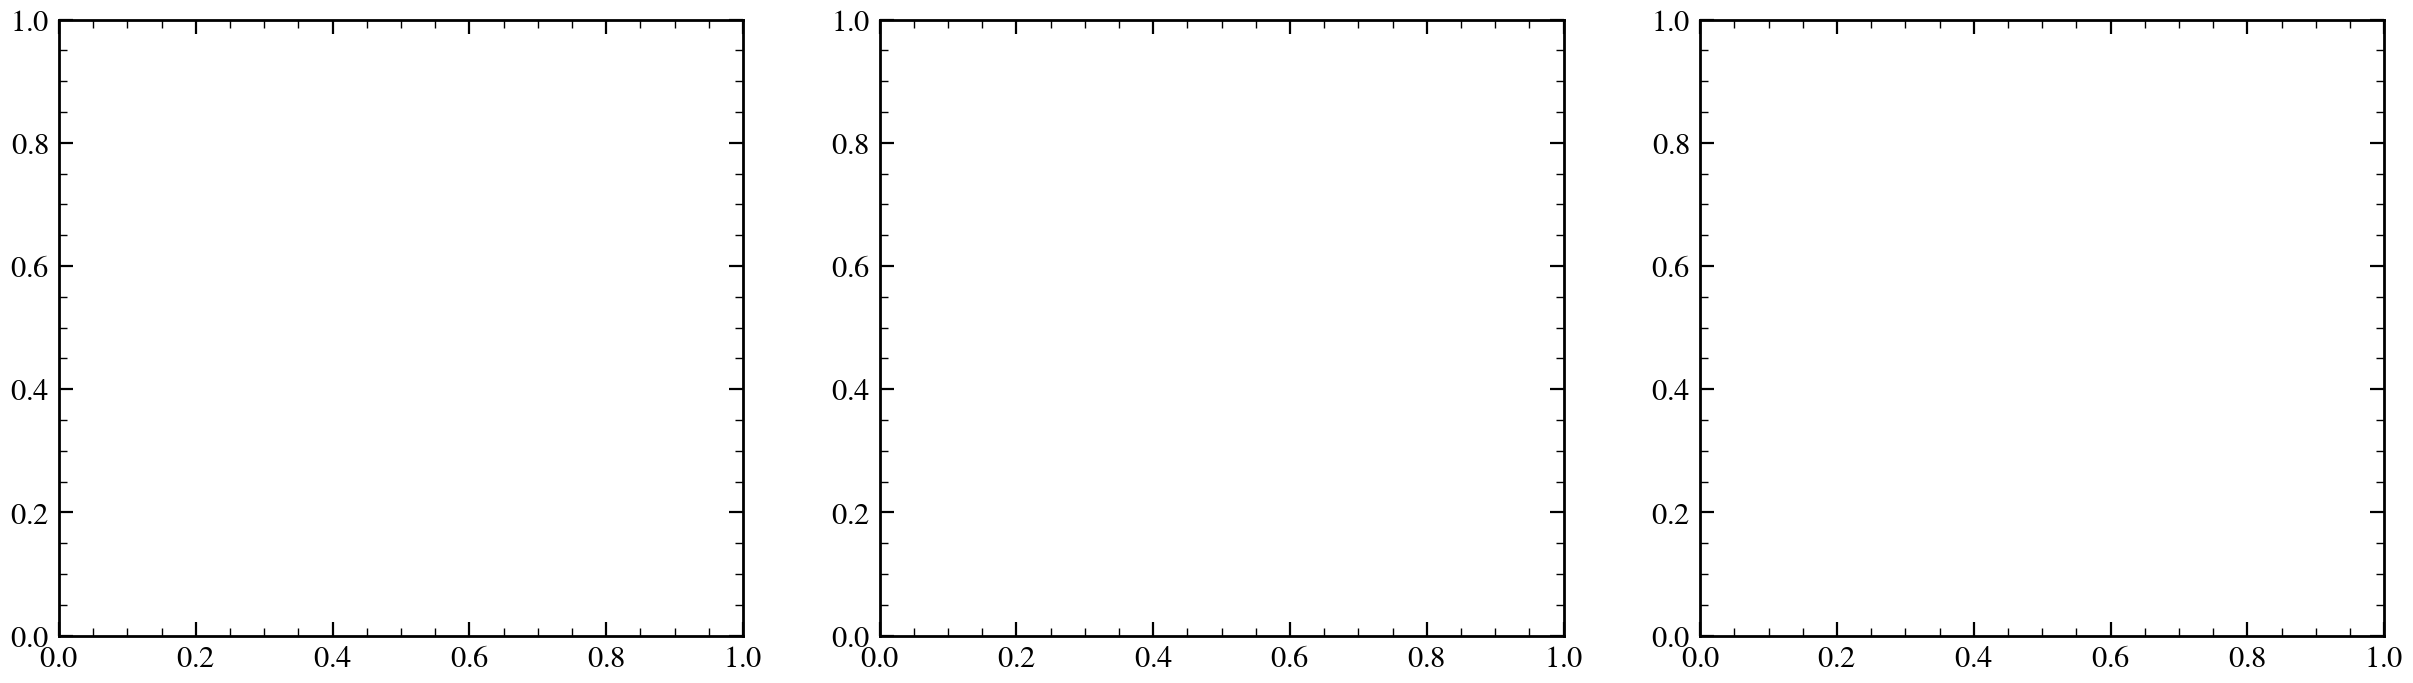

In [5]:
wave_param = jnp.linspace(1000.0, 15000.0, 2000)
k_calz = resolve_dust_law("calzetti")(wave_param)

fig, ax = plt.subplots(figsize=(10, 5))

tau_vs = [0.1, 0.3, 0.5, 1.0, 2.0, 4.0]
tau_colors = plt.cm.YlOrRd(np.linspace(0.2, 0.95, len(tau_vs)))

for tau_val, c in zip(tau_vs, tau_colors):
    transmission = np.exp(-tau_val * np.array(k_calz))
    ax.plot(
        np.array(wave_param),
        transmission,
        color=c,
        lw=2,
        label=rf"$\tau_V = {tau_val}$",
    )

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Transmission $T(\lambda) = \exp(-\tau_V \cdot k)$")
ax.set_title("Calzetti: Transmission at Different Optical Depths")
ax.set_xlim(1000, 15000)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_calzetti_tau_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6b. Kriek-Conroy: Varying $\delta$ (Slope Modification)

The slope parameter $\delta$ tilts the Calzetti curve: negative values
steepen the UV, positive values flatten it (greyer attenuation).

NameError: name 'model' is not defined

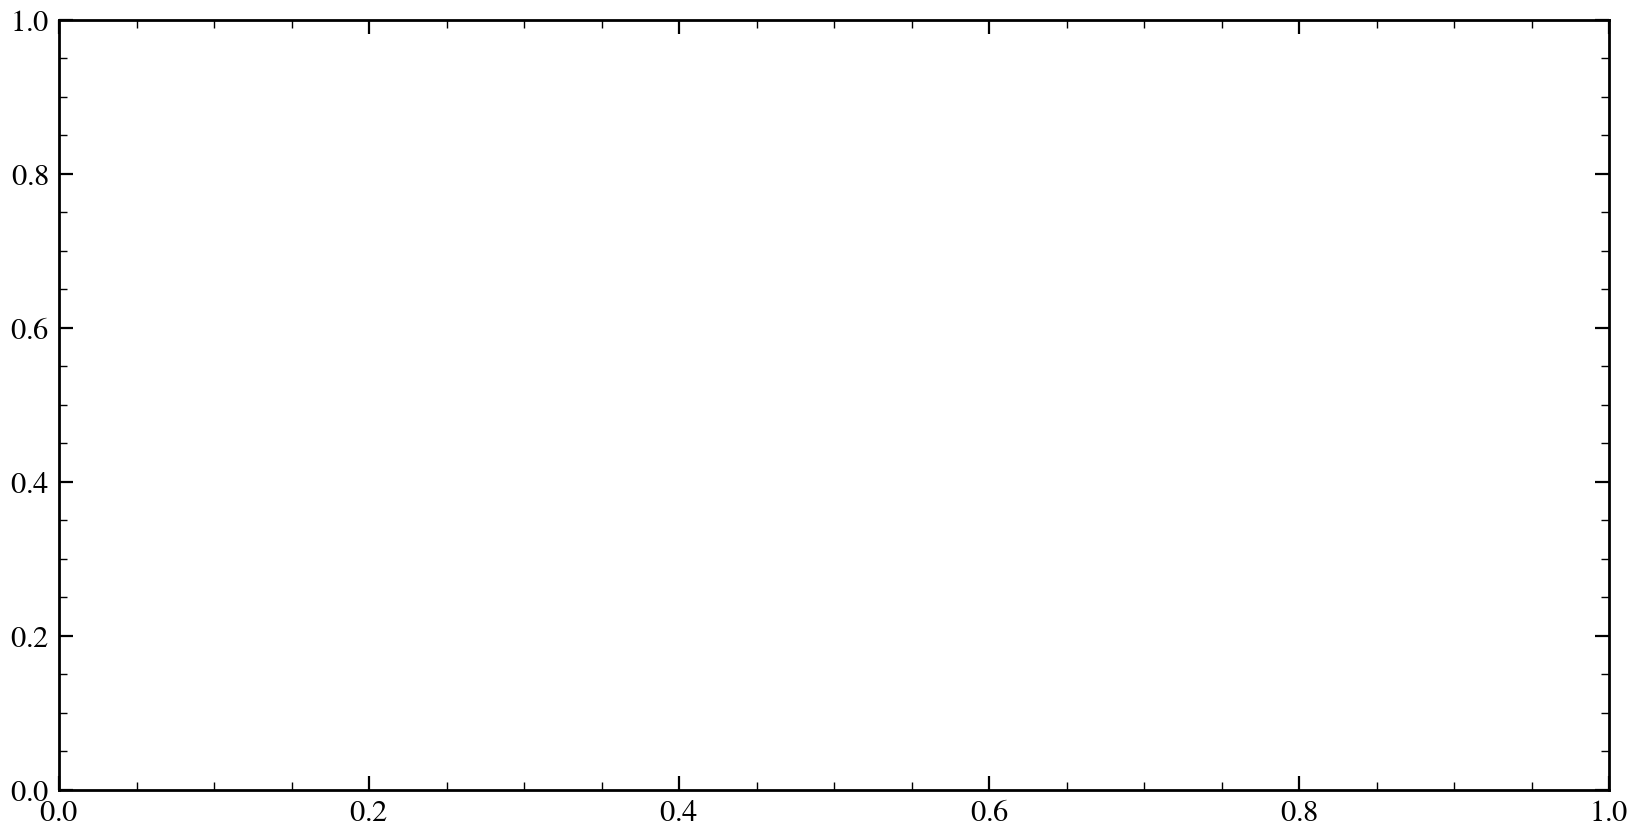

In [6]:
deltas = [-0.5, -0.3, -0.1, 0.0, 0.1, 0.3]
delta_colors = plt.cm.coolwarm(np.linspace(0.0, 1.0, len(deltas)))

fig, ax = plt.subplots(figsize=(6, 4))

for d, c in zip(deltas, delta_colors):
    k = resolve_dust_law("kriek_conroy")(wave_param, dust_delta=d, dust_bump_strength=0.0)
    ax.plot(np.array(wave_param), np.array(k), color=c, lw=2, label=rf"$\delta = {d:+.1f}$")

k_ref = resolve_dust_law("calzetti")(wave_param)
ax.plot(
    np.array(wave_param), np.array(k_ref), color="black", lw=1.5, ls=":", label="Calzetti (ref)"
)

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Kriek-Conroy: Slope Modification ($E_b = 0$)")
ax.set_xlim(1000, 10000)
ax.set_ylim(0, 10)
ax.legend(fontsize=16, ncol=2)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_kc13_delta_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6c. Kriek-Conroy: Varying UV Bump Strength $E_b$

The bump strength $E_b$ adds a Drude profile at 2175 A on top of the
(potentially tilted) Calzetti base.

In [ ]:
bumps = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
bump_colors = plt.cm.Purples(np.linspace(0.3, 0.95, len(bumps)))

fig, ax = plt.subplots(figsize=(10, 5))

for b, c in zip(bumps, bump_colors):
    k = resolve_dust_law("kriek_conroy")(wave_param, dust_delta=0.0, dust_bump_strength=b)
    ax.plot(np.array(wave_param), np.array(k), color=c, lw=2, label=rf"$E_b = {b:.1f}$")

ax.axvline(2175, color="grey", ls="--", alpha=0.3)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Kriek-Conroy: UV Bump Strength ($\delta = 0$)")
ax.set_xlim(1000, 6000)
ax.set_ylim(0, 8)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_kc13_bump_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6d. Cardelli MW: Varying $R_V$

The total-to-selective extinction ratio $R_V$ is the single free parameter
of the Cardelli (CCM89) curve. Lower $R_V$ means smaller grains and steeper
UV extinction; higher $R_V$ is associated with denser regions (grey extinction).
MW average: $R_V = 3.1$; diffuse ISM: 2.0--3.0; dense clouds: 4--5.5.

In [ ]:
rvs = [2.0, 2.5, 3.1, 4.0, 5.0, 5.5]
rv_colors = plt.cm.copper(np.linspace(0.1, 0.9, len(rvs)))

fig, ax = plt.subplots(figsize=(10, 5))

for rv, c in zip(rvs, rv_colors):
    k = resolve_dust_law("cardelli")(wave_param, dust_Rv=rv)
    ax.plot(np.array(wave_param), np.array(k), color=c, lw=2, label=rf"$R_V = {rv:.1f}$")

ax.axvline(2175, color="grey", ls="--", alpha=0.3, label=r"2175 $\AA$ bump")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda) = A(\lambda) / A(V)$")
ax.set_title("Cardelli MW: Effect of $R_V$")
ax.set_xlim(1000, 10000)
ax.set_ylim(0, 12)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_cardelli_rv_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6e. UV Zoom: SMC vs LMC vs Calzetti

A close-up comparison of the three most-used curves in the rest-frame UV
(1000--4000 A), where the differences are most pronounced.

In [ ]:
wave_uv_zoom = jnp.linspace(1000.0, 4000.0, 1000)

fig, ax = plt.subplots(figsize=(8, 5))

for name, label, color, ls in [
    ("calzetti", "Calzetti (C00)", COLORS["rt"], "-"),
    ("smc", "SMC (Pei 1992)", COLORS["vi"], "--"),
    ("lmc", "LMC (Pei 1992)", COLORS["mcmc_nuts"], "-."),
    ("cardelli", "MW (CCM89)", COLORS["vi_linear"], ":"),
]:
    k = resolve_dust_law(name)(wave_uv_zoom)
    ax.plot(np.array(wave_uv_zoom), np.array(k), color=color, ls=ls, lw=2.5, label=label)

ax.axvline(2175, color="grey", ls="--", alpha=0.3)
ax.axvspan(2050, 2300, alpha=0.08, color="purple")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("UV Zoom: Empirical and Extinction Curves")
ax.set_xlim(1000, 4000)
ax.set_ylim(0, 10)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_uv_zoom_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6f. Li et al. (2008): four coefficients $c_1$--$c_4$ (corrected implementation)

Li et al. (2008, ApJ 685, 1046) give a **single closed form** for
$A_\lambda / A_V$ with four dimensionless parameters: a UV--optical continuum
term, a far-UV rise, and a Lorentzian-style 2175 Å bump (their Eq. 1).
In tengri these map to keyword arguments `dust_c1`--`dust_c4` on `li08`
(continuum amplitude, continuum curvature, continuum offset, bump amplitude).

**Correction note.** Older drafts of this gallery (and a mistaken experimental
wrapper) described Li+2008 using separate FUV / UV / optical power-law slopes
plus a Drude bump. That is **not** the published L08 parametrization and has
been removed. The code now follows Li et al. (2008) Eq. (1) and matches the
docstring in `tengri.models.dust.attenuation.li08`.

Below: (left) one-at-a-time sweeps around the **default** $(c_1,c_2,c_3,c_4)
= (6, 4, 2, 0.04); (right) literature **presets** from Markov et al. (2023, 2025)
for MW-like, SMC-like, and Calzetti-like shapes (see `li08` docstring).

In [ ]:
wave_li = jnp.linspace(1000.0, 15000.0, 2000)
_li_defaults = dict(dust_c1=6.0, dust_c2=4.0, dust_c3=2.0, dust_c4=0.04)


def _li08_kw(**overrides):
    kw = {**_li_defaults, **overrides}
    return li08(wave_li, **kw)


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

# c1: overall continuum amplitude
ax = axes[0, 0]
c1_vals = [4.0, 5.0, 6.0, 7.0, 8.0]
c1_colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(c1_vals)))
for c1, c in zip(c1_vals, c1_colors):
    k_curve = _li08_kw(dust_c1=c1)
    ax.plot(np.array(wave_li), np.array(k_curve), color=c, lw=2, label=rf"$c_1 = {c1:.1f}$")
ax.axvline(2175, color="grey", ls="--", alpha=0.35)
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Li+2008: vary $c_1$ (continuum amplitude)")
ax.set_xlim(1000, 15000)
ax.set_ylim(0, 5)
ax.legend(fontsize=7, loc="upper right")

# c2: steepens the UV rise when increased
ax = axes[0, 1]
c2_vals = [2.5, 3.0, 4.0, 5.0, 5.5]
c2_colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(c2_vals)))
for c2, c in zip(c2_vals, c2_colors):
    k_curve = _li08_kw(dust_c2=c2)
    ax.plot(np.array(wave_li), np.array(k_curve), color=c, lw=2, label=rf"$c_2 = {c2:.1f}$")
ax.axvline(2175, color="grey", ls="--", alpha=0.35)
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Li+2008: vary $c_2$ (continuum curvature / UV steepness)")
ax.set_ylim(0, 5)
ax.legend(fontsize=7, loc="upper right")

# c3: shifts continuum level
ax = axes[1, 0]
c3_vals = [1.0, 1.5, 2.0, 2.5, 3.0]
c3_colors = plt.cm.cividis(np.linspace(0.15, 0.9, len(c3_vals)))
for c3, c in zip(c3_vals, c3_colors):
    k_curve = _li08_kw(dust_c3=c3)
    ax.plot(np.array(wave_li), np.array(k_curve), color=c, lw=2, label=rf"$c_3 = {c3:.1f}$")
ax.axvline(2175, color="grey", ls="--", alpha=0.35)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Li+2008: vary $c_3$ (continuum offset)")
ax.set_ylim(0, 5)
ax.legend(fontsize=7, loc="upper right")

# c4: 2175 Å bump (0 = SMC-like smooth UV)
ax = axes[1, 1]
c4_vals = [0.0, 0.02, 0.04, 0.08, 0.12]
c4_colors = plt.cm.magma(np.linspace(0.2, 0.95, len(c4_vals)))
for c4, c in zip(c4_vals, c4_colors):
    k_curve = _li08_kw(dust_c4=c4)
    ax.plot(np.array(wave_li), np.array(k_curve), color=c, lw=2, label=rf"$c_4 = {c4:.2f}$")
ax.axvline(2175, color="grey", ls="--", alpha=0.35)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title(r"Li+2008: vary $c_4$ (2175 $\AA$ bump strength)")
ax.set_xlim(1000, 6000)
ax.set_ylim(0, 5)
ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Li et al. (2008) Eq. (1): effect of each coefficient (defaults: "
    r"$c_1=6$, $c_2=4$, $c_3=2$, $c_4=0.04$)",
    fontsize=12,
    y=1.01,
)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_li08_parameter_sweeps.png"), dpi=150, bbox_inches="tight")
plt.show()

# Presets (Markov+ 2023, 2025; see `li08` docstring)
fig, ax = plt.subplots(figsize=(10, 5))
_presets = [
    ("MW-like", dict(dust_c1=6.0, dust_c2=4.0, dust_c3=2.0, dust_c4=0.04), COLORS["rt"], "-"),
    ("SMC-like", dict(dust_c1=5.0, dust_c2=5.5, dust_c3=1.5, dust_c4=0.0), COLORS["vi"], "--"),
    (
        "Calzetti-like",
        dict(dust_c1=3.5, dust_c2=2.5, dust_c3=3.0, dust_c4=0.0),
        COLORS["mcmc_nuts"],
        "-.",
    ),
]
for label, kw, color, ls in _presets:
    k_curve = li08(wave_li, **kw)
    ax.plot(np.array(wave_li), np.array(k_curve), color=color, ls=ls, lw=2.5, label=label)

k_def = li08(wave_li)
ax.plot(
    np.array(wave_li),
    np.array(k_def),
    color="black",
    lw=1.2,
    ls=":",
    label="tengri default (= MW-like)",
)
ax.axvline(2175, color="grey", ls="--", alpha=0.35)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("Li+2008: literature presets (same functional form, different $c_i$)")
ax.set_xlim(1000, 15000)
ax.set_ylim(0, 5)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_li08_presets.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Dust Geometries (Witt & Gordon 2000)

The same extinction curve produces **very different effective attenuation**
depending on the geometric arrangement of stars and dust:

- **Shell** (foreground screen): $T = \exp(-\tau_V \cdot k)$
- **Cloudy** (homogeneous mix): $T = (1 - e^{-\tau k}) / (\tau k)$ -- greyer
  because near-side stars see less dust.
- **Dusty** (clumpy medium): $T = \exp(-N(1 - e^{-\tau_\mathrm{clump} k}))$ --
  greyest, because photons escape through low-column channels.

Below we compare all three geometries at $\tau_V = 1, 2, 4$ using the
Cardelli MW extinction curve.

In [ ]:
wave_geom = jnp.linspace(1000.0, 15000.0, 2000)
tau_vals = [1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

geom_colors = {
    "Shell": COLORS["rt"],
    "Cloudy": COLORS["vi"],
    "Dusty": COLORS["mcmc_nuts"],
}

for i, tau_val in enumerate(tau_vals):
    ax = axes[i]

    t_shell = wg00_shell(wave_geom, tau_v=tau_val, law="cardelli")
    t_cloudy = wg00_cloudy(wave_geom, tau_v=tau_val, law="cardelli")
    t_dusty = wg00_dusty(wave_geom, tau_v=tau_val, law="cardelli", n_clumps=10.0)

    ax.plot(
        np.array(wave_geom),
        np.array(t_shell),
        color=geom_colors["Shell"],
        lw=2.5,
        label="Shell (screen)",
    )
    ax.plot(
        np.array(wave_geom),
        np.array(t_cloudy),
        color=geom_colors["Cloudy"],
        lw=2.5,
        ls="--",
        label="Cloudy (mixed)",
    )
    ax.plot(
        np.array(wave_geom),
        np.array(t_dusty),
        color=geom_colors["Dusty"],
        lw=2.5,
        ls="-.",
        label="Dusty (clumpy)",
    )

    ax.set_xlabel(r"Wavelength ($\AA$)")
    ax.set_title(rf"$\tau_V = {tau_val:.0f}$")
    ax.set_xlim(1000, 15000)
    ax.set_ylim(0, 1.05)
    if i == 0:
        ax.set_ylabel(r"Transmission $T(\lambda)$")
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("WG00 Dust Geometries: Shell vs Cloudy vs Dusty (MW curve)", fontsize=13, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_wg00_geometries.png"), dpi=150, bbox_inches="tight")
plt.show()

### How clumpy geometry greys the curve

At fixed total $\tau_V$, the dusty (clumpy) geometry has the highest
transmission at all wavelengths, especially in the UV. This is because
photons preferentially escape through low-column sightlines between
clumps. The effect is strongest at high optical depth.

In [ ]:
wave_grey = jnp.linspace(1000.0, 15000.0, 2000)
tau_grey = 3.0

t_shell = wg00_shell(wave_grey, tau_v=tau_grey, law="cardelli")
t_cloudy = wg00_cloudy(wave_grey, tau_v=tau_grey, law="cardelli")
t_dusty = wg00_dusty(wave_grey, tau_v=tau_grey, law="cardelli", n_clumps=10.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: transmission
for t_arr, label, color, ls in [
    (t_shell, "Shell", geom_colors["Shell"], "-"),
    (t_cloudy, "Cloudy", geom_colors["Cloudy"], "--"),
    (t_dusty, "Dusty (N=10)", geom_colors["Dusty"], "-."),
]:
    ax1.plot(np.array(wave_grey), np.array(t_arr), color=color, ls=ls, lw=2.5, label=label)
ax1.set_xlabel(r"Wavelength ($\AA$)")
ax1.set_ylabel(r"Transmission $T(\lambda)$")
ax1.set_title(rf"Transmission at $\tau_V = {tau_grey:.0f}$")
ax1.set_xlim(1000, 15000)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# Right: effective attenuation k_eff = -ln(T) / tau_V
# This shows how geometry "greys" the effective curve
k_eff_shell = -np.log(np.clip(np.array(t_shell), 1e-30, None)) / tau_grey
k_eff_cloudy = -np.log(np.clip(np.array(t_cloudy), 1e-30, None)) / tau_grey
k_eff_dusty = -np.log(np.clip(np.array(t_dusty), 1e-30, None)) / tau_grey

for k_eff, label, color, ls in [
    (k_eff_shell, "Shell (= intrinsic k)", geom_colors["Shell"], "-"),
    (k_eff_cloudy, "Cloudy", geom_colors["Cloudy"], "--"),
    (k_eff_dusty, "Dusty (N=10)", geom_colors["Dusty"], "-."),
]:
    ax2.plot(np.array(wave_grey), k_eff, color=color, ls=ls, lw=2.5, label=label)
ax2.set_xlabel(r"Wavelength ($\AA$)")
ax2.set_ylabel(r"Effective $k_\mathrm{eff}(\lambda) = -\ln T / \tau_V$")
ax2.set_title("Greying Effect of Clumpy Geometry")
ax2.set_xlim(1000, 15000)
ax2.set_ylim(0, 8)
ax2.legend(fontsize=8, loc="upper right")

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_greying_effect.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Two-Component Dust Model

The Charlot & Fall (2000) two-component model applies **separate** dust
attenuation to young and old stars:

- **Birth cloud** ($\tau_\mathrm{bc}$): affects young stars (age $< t_\mathrm{birth}$)
- **Diffuse ISM** ($\tau_\mathrm{diff}$): affects all stars

The transition is a smooth sigmoid in log(age) at $t_\mathrm{birth} = 10\,\mathrm{Myr}$:

$$\tau(\lambda, \mathrm{age}) = w(\mathrm{age}) \cdot \tau_\mathrm{bc} \cdot k_\mathrm{bc}(\lambda)
    + \tau_\mathrm{diff} \cdot k_\mathrm{diff}(\lambda)$$

### 8a. The Age-Dependent Sigmoid Transition

Young stars see both birth cloud + diffuse ISM dust. Old stars see only
the diffuse ISM. The transition weight $w(\mathrm{age})$ is a sigmoid
in $\log_{10}(\mathrm{age})$.

In [ ]:
age_grid = jnp.logspace(5, 10.3, 500)  # 100 kyr to 20 Gyr

fig, ax = plt.subplots(figsize=(10, 4))

for t_birth, c in zip(
    [1e6, 5e6, 1e7, 3e7, 1e8],
    plt.cm.viridis(np.linspace(0.1, 0.9, 5)),
):
    w = precompute_dust_age_weights(age_grid, t_birth=t_birth)
    label_gyr = t_birth / 1e6
    ax.plot(
        np.array(age_grid) / 1e9,
        np.array(w),
        color=c,
        lw=2,
        label=rf"$t_\mathrm{{birth}} = {label_gyr:.0f}$ Myr",
    )

ax.set_xscale("log")
ax.set_xlabel("Stellar age (Gyr)")
ax.set_ylabel(r"Birth cloud weight $w(\mathrm{age})$")
ax.set_title("Sigmoid Transition: Birth Cloud vs Diffuse ISM")
ax.set_xlim(1e-4, 20)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="grey", ls=":", alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "15_sigmoid_transition.png"), dpi=150, bbox_inches="tight")
plt.show()

### 8b. Young vs Old Star Transmission

For fixed $\tau_\mathrm{bc} = 1.0$ and $\tau_\mathrm{diff} = 0.5$ with
the default power-law curve, we show the transmission as a function of
wavelength for different stellar ages.

In [ ]:
wave_2c = jnp.linspace(1000.0, 15000.0, 1000)
ages_show = jnp.array([1e6, 5e6, 1e7, 5e7, 1e8, 1e9, 5e9])

tau_bc = 1.0
tau_diff = 0.5

transmission = two_component_dust(
    wave_2c,
    ages_show,
    tau_v1=tau_bc,
    tau_v2=tau_diff,
    law_bc="power_law",
    law_diff="power_law",
)

fig, ax = plt.subplots(figsize=(10, 5))

age_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(ages_show)))
for i, (age_val, c) in enumerate(zip(ages_show, age_colors)):
    age_myr = float(age_val) / 1e6
    if age_myr >= 1000:
        label = f"{age_myr / 1000:.0f} Gyr"
    else:
        label = f"{age_myr:.0f} Myr"
    ax.plot(
        np.array(wave_2c),
        np.array(transmission[i]),
        color=c,
        lw=2,
        label=label,
    )

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Transmission $T(\lambda, \mathrm{age})$")
ax.set_title(
    rf"Two-Component Dust: $\tau_\mathrm{{bc}} = {tau_bc}$, "
    rf"$\tau_\mathrm{{diff}} = {tau_diff}$ (power law)"
)
ax.set_xlim(1000, 15000)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, title="Stellar age", title_fontsize=9)
fig.tight_layout()
# fig.savefig(
# os.path.join(FIGDIR, "15_two_component_transmission.png"),
# dpi=150,
# bbox_inches="tight",
# )
plt.show()

### 8c. Varying $\tau_\mathrm{bc}$ and $\tau_\mathrm{diff}$ Independently

We show the transmission of a **young** (1 Myr) and **old** (1 Gyr)
stellar population as we independently vary $\tau_\mathrm{bc}$ and
$\tau_\mathrm{diff}$.

In [ ]:
wave_vary = jnp.linspace(1000.0, 15000.0, 1000)
ages_2 = jnp.array([1e6, 1e9])  # 1 Myr (young) and 1 Gyr (old)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left panel: vary tau_bc at fixed tau_diff = 0.3
tau_diff_fixed = 0.3
tau_bc_vals = [0.0, 0.5, 1.0, 2.0, 4.0]
bc_colors = plt.cm.Reds(np.linspace(0.2, 0.9, len(tau_bc_vals)))

for tau_bc_val, c in zip(tau_bc_vals, bc_colors):
    trans = two_component_dust(
        wave_vary,
        ages_2,
        tau_v1=tau_bc_val,
        tau_v2=tau_diff_fixed,
        law_bc="power_law",
        law_diff="power_law",
    )
    ax1.plot(
        np.array(wave_vary),
        np.array(trans[0]),
        color=c,
        lw=2,
        label=rf"$\tau_\mathrm{{bc}} = {tau_bc_val}$ (young)",
    )
    ax1.plot(np.array(wave_vary), np.array(trans[1]), color=c, lw=1.5, ls=":")

ax1.set_xlabel(r"Wavelength ($\AA$)")
ax1.set_ylabel(r"Transmission")
ax1.set_title(rf"Vary $\tau_\mathrm{{bc}}$ (fixed $\tau_\mathrm{{diff}} = {tau_diff_fixed}$)")
ax1.set_xlim(1000, 15000)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, loc="lower right")
ax1.text(
    0.02,
    0.02,
    "Solid = 1 Myr, dotted = 1 Gyr",
    transform=ax1.transAxes,
    fontsize=8,
    color="grey",
)

# Right panel: vary tau_diff at fixed tau_bc = 1.0
tau_bc_fixed = 1.0
tau_diff_vals = [0.0, 0.3, 0.5, 1.0, 2.0]
diff_colors = plt.cm.Blues(np.linspace(0.2, 0.9, len(tau_diff_vals)))

for tau_diff_val, c in zip(tau_diff_vals, diff_colors):
    trans = two_component_dust(
        wave_vary,
        ages_2,
        tau_v1=tau_bc_fixed,
        tau_v2=tau_diff_val,
        law_bc="power_law",
        law_diff="power_law",
    )
    ax2.plot(
        np.array(wave_vary),
        np.array(trans[0]),
        color=c,
        lw=2,
        label=rf"$\tau_\mathrm{{diff}} = {tau_diff_val}$ (young)",
    )
    ax2.plot(np.array(wave_vary), np.array(trans[1]), color=c, lw=1.5, ls=":")

ax2.set_xlabel(r"Wavelength ($\AA$)")
ax2.set_title(rf"Vary $\tau_\mathrm{{diff}}$ (fixed $\tau_\mathrm{{bc}} = {tau_bc_fixed}$)")
ax2.set_xlim(1000, 15000)
ax2.legend(fontsize=7, loc="lower right")
ax2.text(
    0.02,
    0.02,
    "Solid = 1 Myr, dotted = 1 Gyr",
    transform=ax2.transAxes,
    fontsize=8,
    color="grey",
)

fig.suptitle("Two-Component Dust: Independent Parameter Variation", fontsize=13, y=1.02)
fig.tight_layout()
# fig.savefig(
# os.path.join(FIGDIR, "15_two_component_vary.png"),
# dpi=150,
# bbox_inches="tight",
# )
plt.show()

## 9. Summary Table

All attenuation curves implemented in tengri with their key properties.

| Curve | Reference | Free Parameters | UV Bump | Recommended Use Case |
|-------|-----------|----------------|---------|---------------------|
| `power_law` | Charlot & Fall (2000) | `n_slope` | No | Birth cloud attenuation; simplest model |
| `calzetti` | Calzetti et al. (2000) | None ($R_V = 4.05$ fixed) | No | Starburst galaxies; low-$z$ UV/optical |
| `leitherer02` | Leitherer et al. (2002) | None | No | Far-UV extension of Calzetti (970--1800 A) |
| `kriek_conroy` | Kriek & Conroy (2013) | `dust_delta`, `dust_bump_strength` | Optional | Prospector default; most-used modified Calzetti |
| `noll09` | Noll et al. (2009) | `dust_delta`, `dust_bump_strength`, `x0`, `gamma` | Optional | CIGALE default; bump *before* slope |
| `salim_sbl18` | Salim, Boquien & Lee (2018) | `dust_delta`, `dust_bump_strength`, `x0`, `gamma` | Optional | SBL18 ordering (slope then bump) + L02 far-UV |
| `salim` | Salim et al. (2018) | `dust_delta`, `dust_bump_strength` | Optional | DSPS default (identical to KC13) |
| `cardelli` | Cardelli et al. (1989) | `dust_Rv` | Yes (strong) | MW sightlines; extinction (not attenuation) |
| `smc` | Pei (1992) | None | No | High-$z$, metal-poor galaxies |
| `lmc` | Pei (1992) | None | Yes (weak) | Intermediate environments |
| `li08` | Li et al. (2008) | `dust_c1`, `dust_c2`, `dust_c3`, `dust_c4` | Yes ($c_4$ = bump term) | Flexible analytic $A_\lambda/A_V$; literature presets for MW/SMC/Calzetti-like |
| `tea` | Haskell et al. (2024) | `dust_delta`, `scatter` | Correlated | Physics-motivated; fewest free params with bump |
| `conroy2010` | Conroy et al. (2010) | `dust_Rv`, `n_slope` | Yes (MW) | FSPS `dust_type=1`; MW + power-law blend |
| `narayanan_z` | Narayanan et al. (2018) | `dust_delta`, `dust_bump_strength`, `redshift` | Weakens with $z$ | Redshift-evolving attenuation from RT simulations |

**Dust geometries** (Witt & Gordon 2000): `wg00_shell`, `wg00_cloudy`, `wg00_dusty`
convert any extinction curve $k(\lambda)$ into a transmission $T(\lambda)$
accounting for the spatial distribution of stars and dust.

**Two-component model** (Charlot & Fall 2000): `two_component_dust` applies
separate curves with independent $\tau_V$ for birth clouds and diffuse ISM,
with a sigmoid age transition at $t_\mathrm{birth}$.

---
## Age–dust degeneracy (illustration)

Different pairs $(t_\mathrm{peak},\,\tau_\mathrm{diff})$ can yield similar
broadband colours. Below, ``SEDModel.predict_photometry`` maps
``Parameters`` (canonical prefixed names: ``dust_tau_diff``, ``sfh_tsnorm_*``, …)
through the same forward path as inference.

In [ ]:
# Canonical API: ``SEDModel``, ``Parameters``, ``Observation``, ``Photometry``
from tengri import (
    Fixed,
    Observation,
    Parameters,
    Photometry,
    SEDModel,
    Uniform,
    load_ssp_data,
)

ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

In [ ]:
# --- FIGURE 5: tau_diff vs age color (simple illustration) ---
fig, ax = plt.subplots(figsize=(7, 5))

# Compute r-band - i-band color for a grid of (tau_diff, age)
obs_ri = Observation(photometry=Photometry.from_names(["sdss_r", "sdss_i"]))
tau_range = np.linspace(0.0, 1.5, 15)
age_range = np.linspace(1.0, 10.0, 15)
color_grid = np.zeros((len(tau_range), len(age_range)))

for i_t, tau in enumerate(tau_range):
    for i_a, age in enumerate(age_range):
        spec_grid = Parameters(
            sfh_tsnorm_log_peak_sfr=Fixed(1.0),
            sfh_tsnorm_peak_lbt_gyr=Fixed(float(age)),
            sfh_tsnorm_width_gyr=Fixed(2.0),
            sfh_tsnorm_skew=Fixed(0.0),
            sfh_tsnorm_trunc=Fixed(5.0),
            met_logzsol=Fixed(-0.2),
            dust_tau_bc=Fixed(0.0),
            dust_tau_diff=Fixed(float(tau)),
            dust_slope=Fixed(-0.7),
            redshift=Fixed(0.1),
        )
        sed_model = SEDModel(spec_grid, ssp_data, observation=obs_ri)
        params_grid = {
            "sfh_tsnorm_log_peak_sfr": 1.0,
            "sfh_tsnorm_peak_lbt_gyr": float(age),
            "sfh_tsnorm_width_gyr": 2.0,
            "sfh_tsnorm_skew": 0.0,
            "sfh_tsnorm_trunc": 5.0,
            "met_logzsol": -0.2,
            "dust_tau_bc": 0.0,
            "dust_tau_diff": float(tau),
            "dust_slope": -0.7,
            "redshift": 0.1,
        }
        phot = sed_model.predict_photometry(params_grid)
        if phot is not None and len(phot) == 2:
            color_grid[i_t, i_a] = float(phot[0] - phot[1])  # r - i color

im = ax.contourf(age_range, tau_range, color_grid, levels=20, cmap="RdYlBu_r")
plt.colorbar(im, ax=ax, label="r - i color (flux)")
ax.set_xlabel("Peak lookback time [Gyr]")
ax.set_ylabel(r"$\tau_{\rm diff}$")
ax.set_title("Age-Dust Degeneracy: Iso-color Contours")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "03_age_dust_degeneracy.png"), bbox_inches="tight")
plt.show()


tengri implements **10 dust emission models** spanning simple analytic
modified blackbodies through physically-motivated template libraries.
All models are pure JAX (JIT-compatible, fully differentiable) and
enforce energy balance: total IR luminosity = total absorbed luminosity.

This notebook showcases every model, compares their SEDs, and
demonstrates the effect of each parameter.

In [ ]:
import matplotlib.ticker as ticker
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Template file.*not found.*")
warnings.filterwarnings("ignore", message=".*DL07 template.*not found.*")
warnings.filterwarnings("ignore", message=".*Failed to load.*")

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join("models", "figures")
os.makedirs(FIGDIR, exist_ok=True)

In [ ]:
from tengri.models.dust.emission import (
    DUST_EMISSION_MODELS,
    _draine_li2007_analytic_fallback,
    _draine_li2014_analytic_fallback,
    _dale2014_analytic_fallback,
    _astrodust_analytic_fallback,
    _bosa_analytic_fallback,
    _themis_analytic_fallback,
    _pah_template,
    _PAH_CENTER_UM,
    _drude_profile,
    _PAH_FWHM_UM,
    _PAH_STRENGTH,
    _modified_blackbody_component,
    cmb_corrected_temperature,
    cmb_contrast_factor,
    energy_balance_split,
    get_emission_model,
    magphys_dc08,
    modified_blackbody,
    casey2012,
    planck_bnu,
)

## Shared Setup

All models are evaluated on a common rest-frame wavelength grid from
1 to 1000 um (10000 to 10000000 Angstrom) with logarithmic spacing.

In [ ]:
# Wavelength grid: 1--1000 um in Angstrom
wave_aa = jnp.logspace(np.log10(1e4), np.log10(1e7), 2000)
wave_um = wave_aa * 1e-4  # for plotting in microns

# Common parameters
L_ABS = 1e10  # Lsun — total absorbed luminosity

# Color palette for model comparison
MODEL_COLORS = {
    "modified_blackbody": "#1f77b4",
    "casey2012": "#ff7f0e",
    "magphys": "#2ca02c",
    "draine_li2007": "#d62728",
    "draine_li2014": "#9467bd",
    "dale2014": "#8c564b",
    "astrodust": "#e377c2",
    "bosa": "#17becf",
    "themis": "#bcbd22",
    "energy_balance_split": "#7f7f7f",
}

# Consistent line styling
MODEL_LABELS = {
    "modified_blackbody": "Modified BB",
    "casey2012": "Casey (2012)",
    "magphys": "MAGPHYS (dC+08)",
    "draine_li2007": "DL07",
    "draine_li2014": "DL14",
    "dale2014": "Dale+2014",
    "astrodust": "Astrodust+PAH",
    "bosa": "BOSA (B&S21)",
    "themis": "THEMIS (J+17)",
    "energy_balance_split": "Energy Balance Split",
}


def _set_reasonable_log_ylim(ax, pad_log=0.12):
    """Tighten log-scale *y* limits from line data within the axis *x* range."""
    x_lo, x_hi = ax.get_xlim()
    ys = []
    for line in ax.get_lines():
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())
        m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y) & (y > 0)
        if np.any(m):
            ys.append(y[m])
    if not ys:
        return
    y = np.concatenate(ys)
    lo, hi = float(np.min(y)), float(np.max(y))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo <= 0 or hi <= 0:
        return
    if hi / lo < 1.02:
        lo, hi = lo * 0.7, hi * 1.4
    ax.set_ylim(10 ** (np.log10(lo) - pad_log), 10 ** (np.log10(hi) + pad_log))

---
## 1. Overview -- All Models at T=35 K

A single plot comparing every emission model at `L_absorbed = 1e10 Lsun`
and T=35 K (where applicable). Template-based models use their
analytic fallbacks here for guaranteed availability.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- Analytic models ---
# Modified blackbody
lnu_mbb = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8)
ax.plot(
    wave_um,
    np.array(lnu_mbb),
    color=MODEL_COLORS["modified_blackbody"],
    lw=2.0,
    label=MODEL_LABELS["modified_blackbody"],
)

# Casey 2012
lnu_casey = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=2.0)
ax.plot(
    wave_um,
    np.array(lnu_casey),
    color=MODEL_COLORS["casey2012"],
    lw=2.0,
    label=MODEL_LABELS["casey2012"],
)

# MAGPHYS (uses its own temperature parameterization, set warm~35 K)
lnu_magphys = magphys_dc08(
    wave_aa,
    L_ABS,
    dust_T_warm=35.0,
    dust_T_cold=20.0,
    dust_T_hot=180.0,
    dust_xi_pah=0.06,
    dust_xi_mir=0.07,
    dust_xi_warm=0.25,
)
ax.plot(
    wave_um,
    np.array(lnu_magphys),
    color=MODEL_COLORS["magphys"],
    lw=2.0,
    label=MODEL_LABELS["magphys"],
)

# Energy balance split
lnu_ebs = energy_balance_split(wave_aa, L_ABS, dust_T_warm=35.0, dust_T_cold=20.0)
ax.plot(
    wave_um,
    np.array(lnu_ebs),
    color=MODEL_COLORS["energy_balance_split"],
    lw=2.0,
    ls="--",
    label=MODEL_LABELS["energy_balance_split"],
)

# --- Template-based models (analytic fallbacks for guaranteed availability) ---
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
ax.plot(
    wave_um,
    np.array(lnu_dl07),
    color=MODEL_COLORS["draine_li2007"],
    lw=2.0,
    label=f"{MODEL_LABELS['draine_li2007']} (fallback)",
)

lnu_dl14 = _draine_li2014_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5, dust_alpha_dl14=2.0
)
ax.plot(
    wave_um,
    np.array(lnu_dl14),
    color=MODEL_COLORS["draine_li2014"],
    lw=2.0,
    label=f"{MODEL_LABELS['draine_li2014']} (fallback)",
)

lnu_dale = _dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=2.0)
ax.plot(
    wave_um,
    np.array(lnu_dale),
    color=MODEL_COLORS["dale2014"],
    lw=2.0,
    label=f"{MODEL_LABELS['dale2014']} (fallback)",
)

lnu_astro = _astrodust_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=3.0
)
ax.plot(
    wave_um,
    np.array(lnu_astro),
    color=MODEL_COLORS["astrodust"],
    lw=2.0,
    ls="-.",
    label=f"{MODEL_LABELS['astrodust']} (fallback)",
)

lnu_bosa = _bosa_analytic_fallback(wave_aa, L_ABS, dust_log_ssfr=-10.0)
ax.plot(
    wave_um,
    np.array(lnu_bosa),
    color=MODEL_COLORS["bosa"],
    lw=2.0,
    label=f"{MODEL_LABELS['bosa']} (fallback)",
)

lnu_themis = _themis_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=0.17
)
ax.plot(
    wave_um,
    np.array(lnu_themis),
    color=MODEL_COLORS["themis"],
    lw=2.0,
    ls="--",
    label=f"{MODEL_LABELS['themis']} (fallback)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("All Dust Emission Models (overview)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xticks([1, 3, 10, 30, 100, 300, 1000])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_overview_all_models.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Analytic Models

### 2a. Modified Blackbody

The simplest dust emission model: $S_\nu \propto \nu^\beta B_\nu(T)$.
Two free parameters: temperature $T$ and emissivity index $\beta$.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Vary temperature ---
ax = axes[0]
temps = [20, 30, 40, 50, 60]
cmap = plt.cm.inferno
for i, T in enumerate(temps):
    lnu = modified_blackbody(wave_aa, L_ABS, dust_T=float(T), dust_beta_ir=1.8)
    color = cmap(0.2 + 0.7 * i / (len(temps) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"T = {T} K")

    # Mark Wien peak: lambda_peak ~ 2898 / T um (Wien's law, approximate for MBB)
    # Actual peak of nu^beta * B_nu shifts from the simple Wien peak
    peak_idx = int(np.argmax(np.array(lnu)))
    ax.plot(wave_um[peak_idx], np.array(lnu)[peak_idx], "o", color=color, ms=6, zorder=5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Modified Blackbody: vary $T$ ($\beta = 1.8$)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary beta ---
ax = axes[1]
betas = [1.0, 1.5, 2.0, 2.5]
cmap = plt.cm.viridis
for i, beta in enumerate(betas):
    lnu = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=beta)
    color = cmap(0.2 + 0.7 * i / (len(betas) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\beta$ = {beta:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Modified Blackbody: vary $\beta$ ($T = 35$ K)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_modified_blackbody.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2b. Casey (2012)

Extends the modified blackbody with a mid-IR power-law component
to capture the 8--40 um excess from warm dust continuum emission.
The two components are joined by a smooth sigmoid transition function.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Casey vs MBB comparison ---
ax = axes[0]
lnu_mbb = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8)
lnu_c12 = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=2.0)

ax.plot(
    wave_um,
    np.array(lnu_mbb),
    lw=2.0,
    ls="--",
    color=MODEL_COLORS["modified_blackbody"],
    label="Modified BB",
)
ax.plot(wave_um, np.array(lnu_c12), lw=2.0, color=MODEL_COLORS["casey2012"], label="Casey (2012)")

# Shade the mid-IR excess region
lnu_mbb_arr = np.array(lnu_mbb)
lnu_c12_arr = np.array(lnu_c12)
wave_um_arr = np.array(wave_um)
mask_excess = (wave_um_arr >= 3) & (wave_um_arr <= 60)
ax.fill_between(
    wave_um_arr[mask_excess],
    lnu_mbb_arr[mask_excess],
    lnu_c12_arr[mask_excess],
    alpha=0.2,
    color=MODEL_COLORS["casey2012"],
    label="Mid-IR excess",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Casey (2012) vs Modified Blackbody")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary alpha_mir ---
ax = axes[1]
alphas = [1.5, 2.0, 2.5]
cmap = plt.cm.Reds
for i, alpha in enumerate(alphas):
    lnu = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=alpha)
    color = cmap(0.35 + 0.55 * i / (len(alphas) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\alpha_{{MIR}}$ = {alpha:.1f}")

# Reference MBB
ax.plot(wave_um, np.array(lnu_mbb), lw=1.5, ls=":", color="grey", label="MBB (no power law)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Casey (2012): vary $\alpha_{\mathrm{MIR}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_casey2012.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2c. MAGPHYS 4-Component Model (da Cunha, Charlot & Elbaz 2008)

Decomposes dust emission into four physically-motivated components:
1. **PAH features** -- Drude profiles at 3.3, 6.2, 7.7, 8.6, 11.3, 12.7 um
2. **Hot MIR continuum** -- Very small grains near young stars (T ~ 180 K)
3. **Warm birth-cloud grains** -- BC component (T ~ 45 K)
4. **Cold ISM grains** -- Diffuse ISM component (T ~ 20 K)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- Panel 1: All 4 components ---
ax = axes[0, 0]

# Compute each component separately using the magphys decomposition
wavelength_cm = wave_aa * 1e-8
nu = 2.99792458e10 / wavelength_cm

# PAH component
pah_shape = _pah_template(wave_aa)
pah_integral = -jnp.trapezoid(pah_shape, nu)
pah_norm = jnp.where(pah_integral > 0.0, 1.0 / pah_integral, 0.0)
pah_component = pah_shape * pah_norm

# MBB components
hot_component = _modified_blackbody_component(wave_aa, 180.0, 1.5, 0.0)
warm_component = _modified_blackbody_component(wave_aa, 45.0, 1.5, 0.0)
cold_component = _modified_blackbody_component(wave_aa, 20.0, 2.0, 0.0)

xi_pah, xi_mir, xi_warm = 0.06, 0.07, 0.25
xi_cold = 1.0 - xi_pah - xi_mir - xi_warm

ax.plot(
    wave_um,
    np.array(L_ABS * xi_pah * pah_component),
    lw=2.0,
    color="#d62728",
    label=f"PAH ($\\xi_{{PAH}}$ = {xi_pah})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_mir * hot_component),
    lw=2.0,
    color="#ff7f0e",
    label=f"Hot MIR ($\\xi_{{MIR}}$ = {xi_mir})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_warm * warm_component),
    lw=2.0,
    color="#2ca02c",
    label=f"Warm BC ($\\xi_W$ = {xi_warm})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_cold * cold_component),
    lw=2.0,
    color="#1f77b4",
    label=f"Cold ISM ($\\xi_C$ = {xi_cold:.2f})",
)

# Total
lnu_total = magphys_dc08(
    wave_aa,
    L_ABS,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
    dust_T_hot=180.0,
    dust_xi_pah=xi_pah,
    dust_xi_mir=xi_mir,
    dust_xi_warm=xi_warm,
)
ax.plot(wave_um, np.array(lnu_total), lw=2.5, color="k", ls="--", label="Total", zorder=5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("MAGPHYS: 4 Components")
ax.set_xlim(1, 1000)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: PAH Drude profiles (zoom on 3--15 um) ---
ax = axes[0, 1]

# Fine wavelength grid for PAH features
wave_pah_aa = jnp.linspace(2e4, 15e4, 1000)  # 2--15 um
wave_pah_um = wave_pah_aa * 1e-4

pah_emission = _pah_template(wave_pah_aa)
ax.plot(wave_pah_um, np.array(pah_emission), lw=2.0, color="#d62728")

# Annotate each feature
pah_labels = ["3.3", "6.2", "7.7", "8.6", "11.3", "12.7"]
for j, lbl in enumerate(pah_labels):
    center = float(_PAH_CENTER_UM[j])
    ax.axvline(center, color="grey", ls=":", lw=0.8, alpha=0.7)
    ax.text(
        center,
        np.max(np.array(pah_emission)) * 1.05,
        f"{lbl}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#555555",
    )

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel("PAH emission (arb.)")
ax.set_title(r"PAH Drude Profiles (Smith+2007)")
ax.set_xlim(2, 15)
_emax = float(np.max(np.array(pah_emission)))
ax.set_ylim(0, _emax * 1.2)

# --- Panel 3: Vary xi_pah ---
ax = axes[1, 0]
xi_pah_values = [0.0, 0.03, 0.06, 0.10, 0.15]
cmap = plt.cm.magma
for i, xp in enumerate(xi_pah_values):
    color = cmap(0.15 + 0.7 * i / (len(xi_pah_values) - 1))
    # Adjust xi_warm to keep sum <= 1
    xw = max(0.0, 0.25 - max(0, xp - 0.06))
    lnu = magphys_dc08(wave_aa, L_ABS, dust_xi_pah=xp, dust_xi_mir=0.07, dust_xi_warm=xw)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\xi_{{PAH}}$ = {xp:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"MAGPHYS: vary $\xi_{\mathrm{PAH}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 4: Vary T_warm and T_cold ---
ax = axes[1, 1]
temp_pairs = [
    (35, 15, "T_w=35, T_c=15 K"),
    (45, 20, "T_w=45, T_c=20 K"),
    (55, 25, "T_w=55, T_c=25 K"),
    (65, 30, "T_w=65, T_c=30 K"),
]
cmap = plt.cm.coolwarm
for i, (tw, tc, lbl) in enumerate(temp_pairs):
    color = cmap(0.15 + 0.7 * i / (len(temp_pairs) - 1))
    lnu = magphys_dc08(wave_aa, L_ABS, dust_T_warm=float(tw), dust_T_cold=float(tc))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=lbl)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"MAGPHYS: vary $T_{\mathrm{warm}}$ and $T_{\mathrm{cold}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_magphys_components.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Template-Based Models

Template-based models auto-load tabulated grids from `data/` on first
call. If templates are not found, they fall back to crude analytic
approximations (shown here with "(fallback)" labels). The fallbacks
are NOT suitable for science.

### 3a. Draine & Li 2007

Three parameters: `qPAH` (PAH mass fraction), `Umin` (minimum
radiation field intensity), `gamma` (fraction in PDR component).

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

# --- Panel 1: Vary qPAH ---
ax = axes[0]
qpah_values = [0.47, 1.5, 2.5, 4.58]
cmap = plt.cm.YlOrRd
for i, qp in enumerate(qpah_values):
    color = cmap(0.25 + 0.65 * i / (len(qpah_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=qp
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$q_{{PAH}}$ = {qp}%")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $q_{\mathrm{PAH}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary Umin ---
ax = axes[1]
umin_values = [0.5, 1.0, 5.0, 10.0]
cmap = plt.cm.Blues
for i, um in enumerate(umin_values):
    color = cmap(0.3 + 0.6 * i / (len(umin_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=um, dust_gamma_dl=0.01, dust_qpah=2.5
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$U_{{min}}$ = {um}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $U_{\mathrm{min}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 3: Vary gamma (single-U vs PDR mix) ---
ax = axes[2]
gamma_values = [0.001, 0.01, 0.05, 0.20]
cmap = plt.cm.Greens
for i, gam in enumerate(gamma_values):
    color = cmap(0.3 + 0.6 * i / (len(gamma_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=gam, dust_qpah=2.5
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\gamma$ = {gam}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $\gamma$ (PDR fraction)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_draine_li2007.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3b. Draine & Li 2014

Extension of DL07 with a free `alpha` parameter controlling the
distribution of radiation field intensities in the PDR component.
DL07 uses a fixed alpha=2.0.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# DL07 reference
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.05, dust_qpah=2.5
)
ax.plot(
    wave_um, np.array(lnu_dl07), lw=2.5, color="k", ls="--", label=r"DL07 ($\alpha$ = 2.0 fixed)"
)

# DL14 with varying alpha
alpha_values = [1.5, 2.0, 2.5, 3.0]
cmap = plt.cm.plasma
for i, alpha in enumerate(alpha_values):
    color = cmap(0.15 + 0.7 * i / (len(alpha_values) - 1))
    lnu = _draine_li2014_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.05, dust_qpah=2.5, dust_alpha_dl14=alpha
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"DL14 $\alpha$ = {alpha:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("DL14 vs DL07: effect of free alpha parameter")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_draine_li2014.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3c. Dale+2014

One-parameter family of IR templates parameterized by alpha, which
controls the power-law distribution of dust heating intensities.
Low alpha = intense radiation field (warmer). High alpha = weak
radiation field (cooler).

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

alpha_dale_values = [1.0, 1.5, 2.0, 2.5, 3.0]
cmap = plt.cm.RdYlBu_r
for i, alpha in enumerate(alpha_dale_values):
    color = cmap(0.1 + 0.8 * i / (len(alpha_dale_values) - 1))
    lnu = _dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=alpha)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\alpha$ = {alpha:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Dale+2014: vary $\alpha$ (radiation field distribution)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])

# Annotate warm/cold trend
ax.annotate(
    "warm (intense UV)",
    xy=(
        30,
        np.max(np.array(_dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=1.0))) * 0.8,
    ),
    fontsize=9,
    color=cmap(0.1),
    style="italic",
)
ax.annotate(
    "cold (weak UV)",
    xy=(
        200,
        np.max(np.array(_dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=3.0))) * 0.5,
    ),
    fontsize=9,
    color=cmap(0.9),
    style="italic",
)
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_dale2014.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3d. Astrodust+PAH (Hensley & Draine 2023)

Updated grain model from the Draine group. Uses observationally-derived
grain opacities (the "astrodust" model) rather than a mix of silicate
and graphite grains. Same mixing formula as DL07 but with different
underlying grain physics.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# Compare DL07 and Astrodust at same parameters
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
lnu_astro = _astrodust_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=3.0
)

ax.plot(
    wave_um,
    np.array(lnu_dl07),
    lw=2.0,
    color=MODEL_COLORS["draine_li2007"],
    label="DL07 ($q_{PAH}$=2.5%)",
)
ax.plot(
    wave_um,
    np.array(lnu_astro),
    lw=2.0,
    color=MODEL_COLORS["astrodust"],
    label="Astrodust ($q_{PAH}$=3.0%)",
)

# Show qPAH variation for Astrodust
for qp, ls in [(1.0, ":"), (5.0, "-.")]:
    lnu = _astrodust_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=qp
    )
    ax.plot(
        wave_um,
        np.array(lnu),
        lw=1.5,
        ls=ls,
        color=MODEL_COLORS["astrodust"],
        label=f"Astrodust ($q_{{PAH}}$={qp}%)",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Astrodust+PAH vs DL07")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_astrodust.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3e. BOSA (Boquien & Salim 2021)

Parameterized by (L_TIR, sSFR) rather than radiation field parameters.
High sSFR galaxies have warmer dust. This provides a direct
connection between star formation activity and dust temperature.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ssfr_values = [-11.0, -10.0, -9.5, -9.0, -8.5]
cmap = plt.cm.hot_r
for i, ssfr in enumerate(ssfr_values):
    color = cmap(0.15 + 0.7 * i / (len(ssfr_values) - 1))
    lnu = _bosa_analytic_fallback(wave_aa, L_ABS, dust_log_ssfr=ssfr)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"log sSFR = {ssfr:.1f}")

# Reference DL07
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
ax.plot(wave_um, np.array(lnu_dl07), lw=1.5, ls="--", color="grey", label="DL07 reference")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"BOSA: sSFR dependence (higher sSFR $\rightarrow$ warmer)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_bosa.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3f. THEMIS (Jones et al. 2017)

Based on the THEMIS/DustEM grain model. Uses `qhac` (a-C(:H) aromatic
carbon mass fraction) instead of `qPAH`. Different grain compositions
lead to different aromatic feature profiles and FIR/submm slopes.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: THEMIS vs DL07 ---
ax = axes[0]
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
lnu_themis = _themis_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=0.17
)

ax.plot(
    wave_um,
    np.array(lnu_dl07),
    lw=2.0,
    color=MODEL_COLORS["draine_li2007"],
    label="DL07 ($q_{PAH}$=2.5%)",
)
ax.plot(
    wave_um,
    np.array(lnu_themis),
    lw=2.0,
    color=MODEL_COLORS["themis"],
    label="THEMIS ($q_{hac}$=0.17)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("THEMIS vs DL07")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary qhac ---
ax = axes[1]
qhac_values = [0.05, 0.10, 0.17, 0.25, 0.30]
cmap = plt.cm.Oranges
for i, qh in enumerate(qhac_values):
    color = cmap(0.25 + 0.65 * i / (len(qhac_values) - 1))
    lnu = _themis_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=qh
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$q_{{hac}}$ = {qh:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"THEMIS: vary $q_{\mathrm{hac}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_themis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Energy Balance

The `energy_balance_split` model decomposes IR emission into warm
and cold components, with `eta_balance` controlling whether total
re-emission exactly equals absorbed luminosity (eta=1) or deviates
from strict energy balance (eta != 1).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Warm + cold decomposition ---
ax = axes[0]

L_abs_stellar = 1e10
f_cold = 0.5
eta = 1.0
L_agn = 0.0

# Full model
lnu_full = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=f_cold,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Warm component only (f_cold=0)
lnu_warm = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=0.0,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Cold component only (f_cold=1)
lnu_cold = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=1.0,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Scale warm/cold to their actual fractions
ax.plot(wave_um, np.array(lnu_full), lw=2.5, color="k", label="Total")
ax.plot(
    wave_um, np.array(0.5 * lnu_warm), lw=2.0, ls="--", color="#d62728", label="Warm (T=45 K, 50%)"
)
ax.plot(
    wave_um, np.array(0.5 * lnu_cold), lw=2.0, ls="--", color="#1f77b4", label="Cold (T=20 K, 50%)"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Energy Balance Split: warm + cold")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary eta_balance and AGN contribution ---
ax = axes[1]

# Vary eta
eta_values = [0.5, 1.0, 1.5]
for eta_val, ls, clr in zip(eta_values, ["-.", "-", "--"], ["#9467bd", "k", "#ff7f0e"]):
    lnu = energy_balance_split(
        wave_aa,
        L_abs_stellar,
        L_agn_ir=0.0,
        eta_balance=eta_val,
        f_cold=0.5,
        dust_T_warm=45.0,
        dust_T_cold=20.0,
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, ls=ls, color=clr, label=rf"$\eta$ = {eta_val:.1f}")

# With AGN contribution
lnu_agn = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=5e9,  # 50% extra from AGN
    eta_balance=1.0,
    f_cold=0.3,
    dust_T_warm=55.0,
    dust_T_cold=20.0,
)
ax.plot(
    wave_um,
    np.array(lnu_agn),
    lw=2.0,
    ls=":",
    color="#d62728",
    label=r"$\eta$=1 + AGN IR ($5\times10^9$ L$_\odot$)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Energy Balance: $\eta$ and AGN contribution")
ax.set_xlim(1, 1000)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_energy_balance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. CMB Corrections

At high redshift, the CMB sets a temperature floor on dust grains
and suppresses the observed Rayleigh-Jeans tail (da Cunha+2013).
The effective dust temperature becomes:

$$T_{\mathrm{eff}} = \left(T_{\mathrm{dust}}^{4+\beta} + T_{\mathrm{CMB}}(z)^{4+\beta} - T_{\mathrm{CMB}}(0)^{4+\beta}\right)^{1/(4+\beta)}$$

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: T_eff vs T_dust at various redshifts ---
ax = axes[0]
T_dust_arr = np.linspace(10, 60, 100)
redshifts = [0, 3, 5, 7]
cmap = plt.cm.cool
for i, z in enumerate(redshifts):
    T_eff_arr = np.array(
        [float(cmb_corrected_temperature(float(T), float(z))) for T in T_dust_arr]
    )
    color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
    ax.plot(T_dust_arr, T_eff_arr, lw=2.0, color=color, label=f"z = {z}")

ax.plot([10, 60], [10, 60], ls=":", color="grey", lw=1.0, alpha=0.7, label="T_eff = T_dust")

# Mark T_CMB(z) floor
for i, z in enumerate(redshifts):
    T_cmb = 2.725 * (1 + z)
    if T_cmb < 60:
        color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
        ax.axhline(T_cmb, color=color, ls="--", lw=0.8, alpha=0.5)

ax.set_xlabel(r"Intrinsic $T_{\mathrm{dust}}$ [K]")
ax.set_ylabel(r"Effective $T_{\mathrm{eff}}$ [K]")
ax.set_title(r"CMB heating: $T_{\mathrm{eff}}$ vs $T_{\mathrm{dust}}$")
ax.legend(fontsize=9)
ax.set_xlim(10, 60)
ax.set_ylim(10, 60)

# --- Panel 2: Effect on FIR SED ---
ax = axes[1]
T_dust_ref = 30.0

for i, z in enumerate(redshifts):
    color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
    lnu = modified_blackbody(
        wave_aa, L_ABS, dust_T=T_dust_ref, dust_beta_ir=1.8, redshift=float(z)
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"z = {z}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"CMB suppression: MBB at $T_{\mathrm{dust}}$ = 30 K")
ax.set_xlim(10, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_cmb_corrections.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Summary Table

All 10 dust emission models in tengri.

In [ ]:
summary_data = [
    ["modified_blackbody", "Analytic", "dust_T, dust_beta_ir", "None", "Hildebrand (1983)"],
    [
        "casey2012",
        "Analytic",
        "dust_T, dust_beta_ir, dust_alpha_mir",
        "None (MIR power law)",
        "Casey (2012)",
    ],
    [
        "magphys",
        "Analytic",
        "T_warm, T_cold, T_hot, xi_pah, xi_mir, xi_warm",
        "Drude profiles (Smith+07)",
        "da Cunha+2008",
    ],
    [
        "draine_li2007",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah",
        "Full treatment (silicate+graphite)",
        "Draine & Li (2007)",
    ],
    [
        "draine_li2014",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah, dust_alpha_dl14",
        "Full treatment (updated)",
        "Draine & Li (2014)",
    ],
    ["dale2014", "Tabulated", "dust_alpha_dale", "Embedded in templates", "Dale+2014"],
    [
        "astrodust",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah",
        "Astrodust+PAH grains",
        "Hensley & Draine (2023)",
    ],
    ["bosa", "Tabulated", "dust_log_ssfr", "Embedded in templates", "Boquien & Salim (2021)"],
    [
        "themis",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qhac",
        "a-C(:H) aromatics (DustEM)",
        "Jones+2017",
    ],
    [
        "energy_balance_split",
        "Analytic",
        "eta_balance, f_cold, T_warm, T_cold, L_agn_ir",
        "None (two MBBs)",
        "Kokorev+2021",
    ],
]

headers = ["Model", "Type", "Parameters", "PAH Treatment", "Reference"]

# Print table
print(
    f"{'Model':<22s} {'Type':<11s} {'Parameters':<50s} {'PAH Treatment':<30s} {'Reference':<25s}"
)
print("-" * 138)
for row in summary_data:
    print(f"{row[0]:<22s} {row[1]:<11s} {row[2]:<50s} {row[3]:<30s} {row[4]:<25s}")

In [ ]:
# Also display as a formatted figure table
fig, ax = plt.subplots(figsize=(13, 4.0))
ax.axis("off")

table = ax.table(
    cellText=summary_data,
    colLabels=headers,
    cellLoc="left",
    loc="center",
    colWidths=[0.14, 0.07, 0.32, 0.22, 0.16],
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.6)

# Style header row
for j in range(len(headers)):
    cell = table[0, j]
    cell.set_facecolor("#333333")
    cell.set_text_props(color="white", fontweight="bold")

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    bg = "#f0f0f0" if i % 2 == 0 else "white"
    for j in range(len(headers)):
        table[i, j].set_facecolor(bg)

ax.set_title("tengri Dust Emission Models", fontsize=14, fontweight="bold", pad=20)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "16_summary_table.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Notes

- Template-based models (DL07, DL14, Dale+2014, Astrodust, BOSA, THEMIS)
  auto-load tabulated grids from `data/` on first call. If templates
  are not found, crude analytic fallbacks are used with a warning.
  The fallbacks shown in this notebook are **not suitable for science**.

- All models enforce energy balance: the frequency integral of the
  emission SED equals `L_absorbed` (the total luminosity absorbed by
  dust in the UV/optical attenuation step).

- CMB corrections (da Cunha+2013) are applied automatically when
  `redshift > 0`. This affects the effective dust temperature and
  suppresses the Rayleigh-Jeans tail.

- The `energy_balance_split` model extends simple energy balance
  with warm/cold decomposition and optional AGN IR contribution.
  The `eta_balance` parameter allows departures from strict energy
  balance (spatial offsets between UV and FIR emission regions).